In [2]:
import numpy as np
import pandas as pd

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_confidence_intervals_deviation, plot_heatmap
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.evaluate import evaluate_result
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator

from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator, DateFormatter


/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def plot_viral_composition(counts, freq = None, composition_estimate = None, var_names = None, y_range = (1e-5, 2), logscale = True, start_date= None):

    plt.figure(figsize=(counts.shape[0] // 50, 8))
    
    base_colors = [
        "#a6444f",  # reddish
        "#57a8b8",  # teal
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#397398",  # dark blue
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]


    brighter_colors = [
    "#6baed6",  # lighter blue
    "#ffae6b",  # lighter orange
    "#66c266",  # lighter green
    "#ff6666",  # lighter red
    "#c2a5e2",  # lighter purple
    "#b38f87",  # lighter brown
    "#f7a6d8",  # lighter pink
    "#bfbfbf",  # lighter gray
    "#d4e157",  # lighter olive
    "#66ddee"   # lighter cyan
    ]

    n_samples = np.sum(counts, axis = 1)
    rel_abund = counts / n_samples[:, np.newaxis]

    if var_names is None:
        var_names = [f'Variant {i+1}' for i in range(counts.shape[1])]

    # Create time labels
    days = np.arange(counts.shape[0])
    if start_date is not None:
        time_labels = [datetime.strptime(start_date, "%Y-%m-%d") + timedelta(days=int(day)) for day in days]
    else:
        time_labels = days

    for i in range(counts.shape[1]):

        plt.scatter(time_labels, rel_abund[:, i], s= 10, alpha = 0.3, label = var_names[i], color = base_colors[i % 8])
        if freq is not None:
            plt.plot(time_labels, freq[:, i], color = base_colors[i % 8])
        if composition_estimate is not None:
            plt.plot(time_labels, composition_estimate[:, i], color = brighter_colors[i % 10], linestyle='--')

    plt.xlabel("Date" if isinstance(time_labels[0], datetime) else "Days", size=14)
    plt.ylabel("Abundancy [%]", size=14)
    if(logscale):
        plt.yscale('log')
        plt.ylim(y_range)
    plt.title("Disease Variants in Population", size=16)

    if start_date:
        ax = plt.gca()
        ax.xaxis.set_major_locator(MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
        plt.gcf().autofmt_xdate()

    plt.tick_params(axis='both', which='major', labelsize=12)

    if(counts.shape[1] > 10):
        #plt.legend(ncol = 10, loc='upper center', bbox_to_anchor=(0.5, -0.15))    #counts.shape[1] // 7
        print("Too many variants to show legend")
    else:
        plt.legend()
    plt.grid(False)
    plt.tight_layout()
    #plt.savefig("figures/variant_comp.pdf", dpi=1000, bbox_inches='tight')
    plt.show()




In [15]:
n_variants = 200
n_days = 800
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0, reorder=True) #data reordered from start


#np.savez('data/count_data.npz', **data)
# to reload: np.load('data/count_data.npz')

Too many variants to show legend


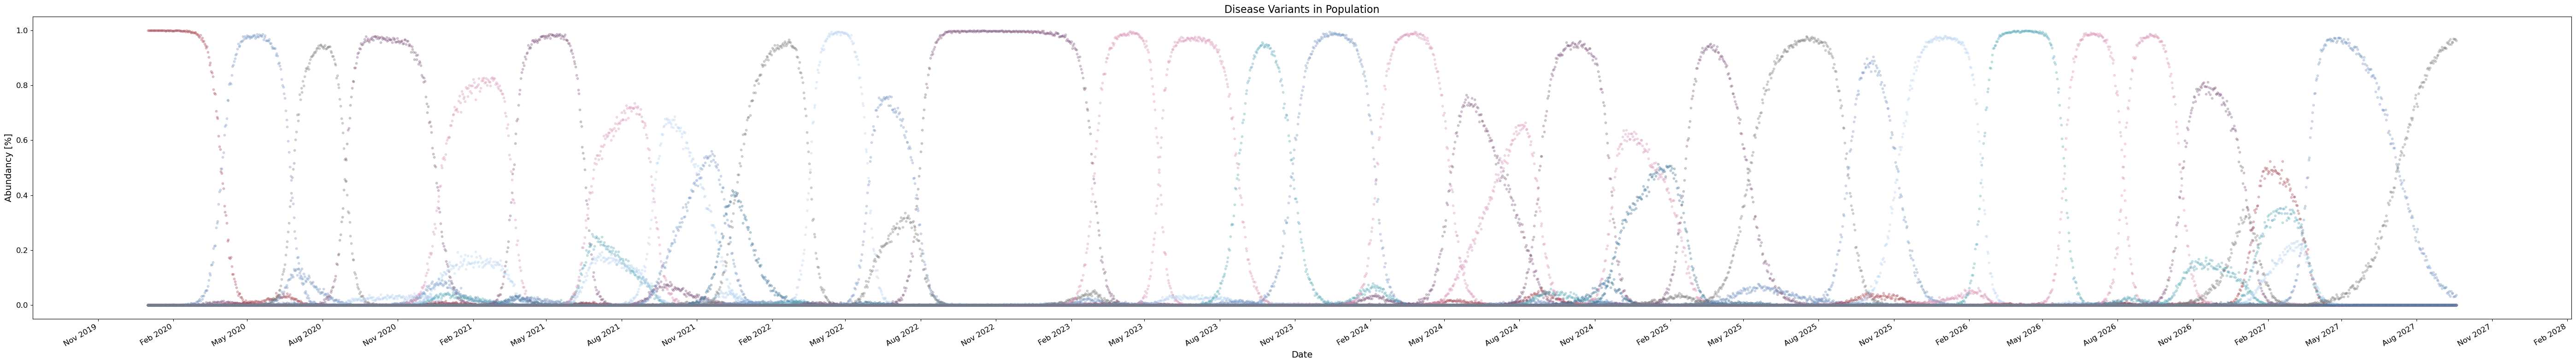

In [16]:
plot_viral_composition(data['counts'], y_range = (1e-5, 2), logscale=False, start_date="2020-01-01")

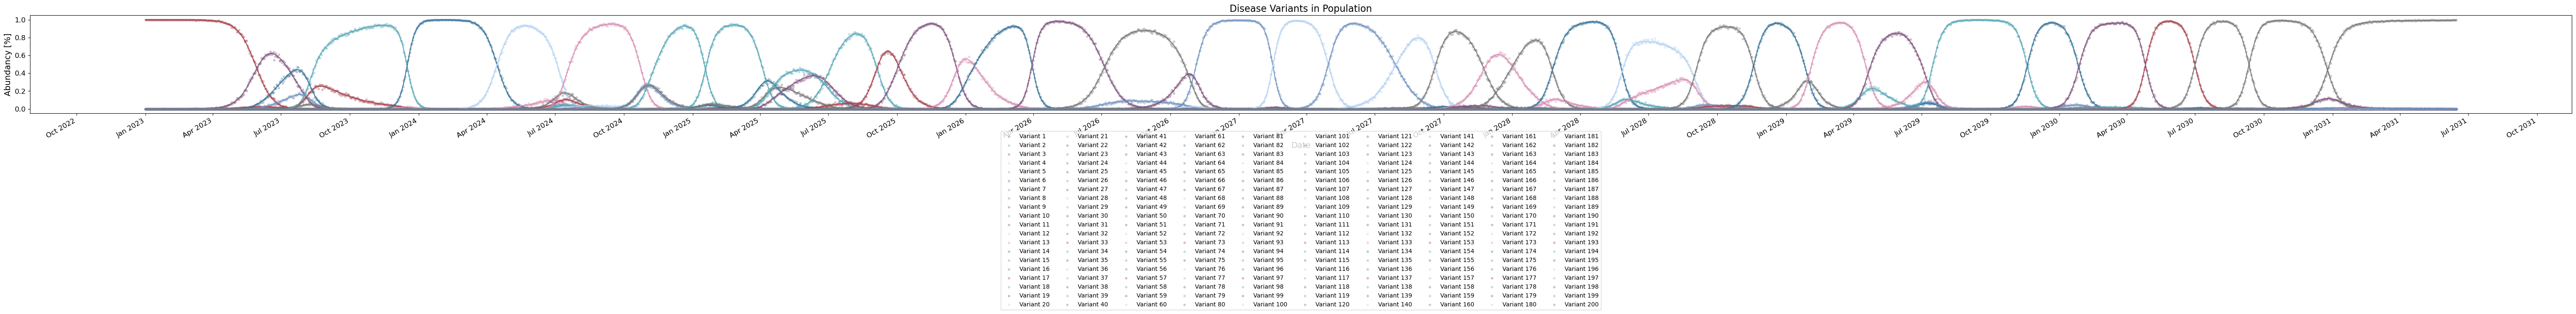

In [6]:
plot_viral_composition(data['counts'], data['freq'], y_range = (1e-5, 2), logscale=False, start_date="2023-01-01")

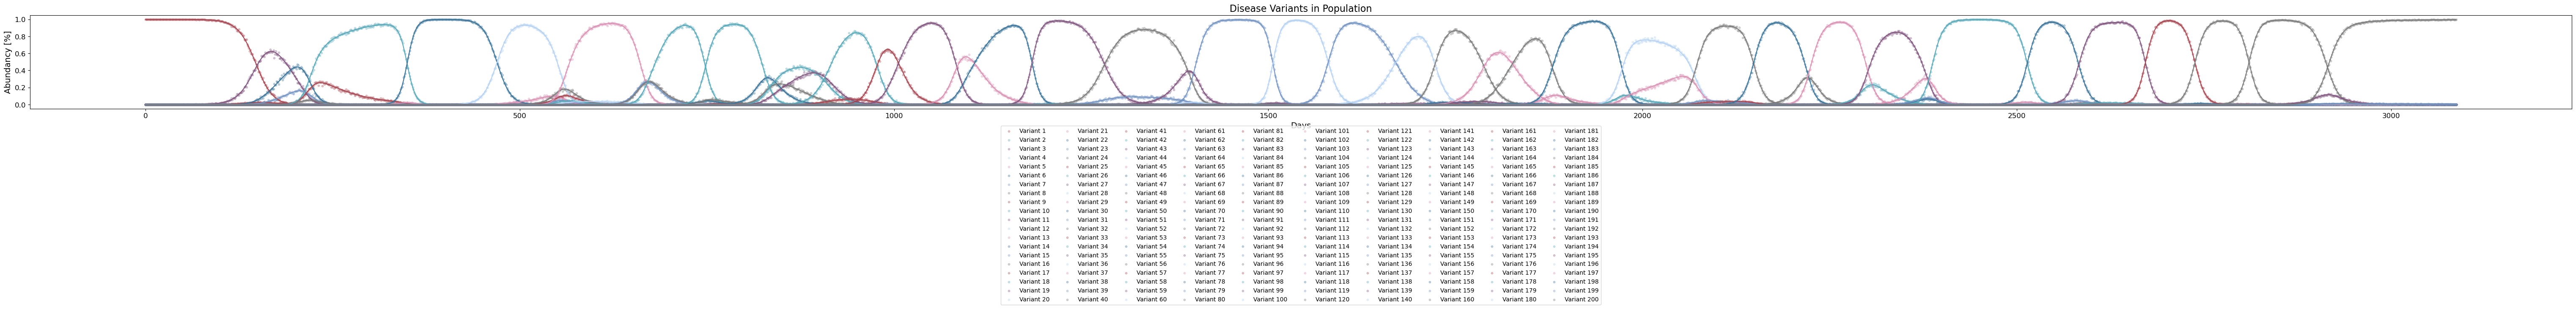

In [7]:
plot_viral_composition(data['counts'], data['freq'], y_range = (1e-5, 2), logscale=False)